In [1]:
import os
from pathlib import Path

import geopandas as gpd

from urban_clusters.denue import filter_jobs_by_geometry, load_jobs_dataframe

In [2]:
import contextily as cx
import matplotlib.pyplot as plt
import seaborn as sns
from photutils.utils import make_random_cmap
from scipy.spatial.distance import jensenshannon, pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from urban_clusters.economic import get_distribution_df
from urban_clusters.plot import (
    plot_centroids,
    plot_cluster_distribution,
    plot_location_quotient,
    plot_num_jobs,
)
from urban_clusters.spatial import (
    generate_hulls,
)

In [3]:
data_path = Path(os.environ["DATA_PATH"])
generated_path = data_path / "generated"
figure_path = data_path / "docs" / "main" / "fig"
population_grids_path = Path(os.environ["POPULATION_GRIDS_PATH"])

results_path = Path("./results")
results_path.mkdir(exist_ok=True)

# Groups

In [4]:
groups = [
    ["19039", "19019", "19048", "19018", "19021", "19046", "19026", "19006"],
    ["19031"],
    ["19009", "19041"],
    ["19004", "19049"],
    ["19045", "19012", "19025"],
]

In [5]:
df_jobs = load_jobs_dataframe()

In [6]:
df_geom = gpd.read_file(
    population_grids_path / "final" / "framework" / "mun" / "2020.gpkg",
)

points = []
for i, group in enumerate(groups):
    df_group = df_geom[df_geom["CVEGEO"].isin(group)]
    merged = df_group.union_all()
    out = filter_jobs_by_geometry(df_jobs, merged).rename(
        columns={"num_empleos_esperados": "jobs", "codigo_act": "scian"},
    )
    out.to_file(f"./points/group_{i}.gpkg")

# Economic

In [186]:
h = "0fa11f0e"
df_points = gpd.read_file(f"./cache/{h}/clusters.gpkg")

In [187]:
df_polygons = generate_hulls(
    df_points,
    cluster_col="spatial_cluster",
    buffer=0,
).set_index("spatial_cluster")

In [188]:
df_counts = get_distribution_df(
    df_points,
    level=3,
    normalize=True,
    cluster_col="spatial_cluster",
)
distance_mat = squareform(pdist(df_counts.to_numpy(), metric=jensenshannon))

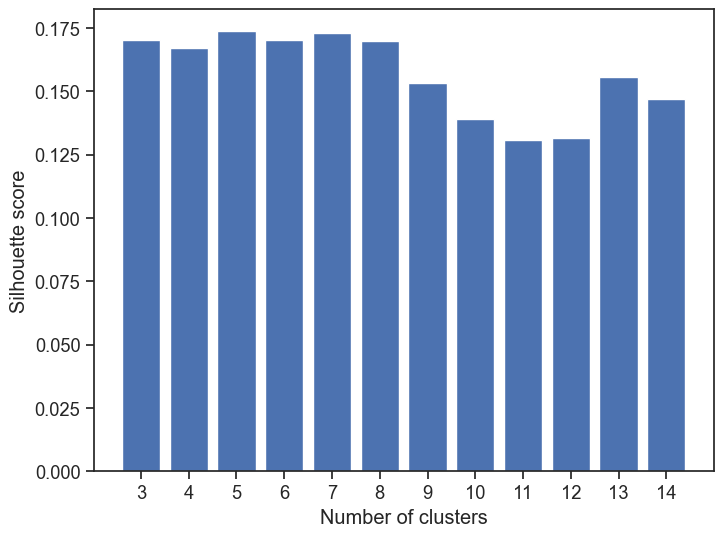

In [189]:
x, y = [], []
for n_clusters in range(3, 15):
    model = AgglomerativeClustering(
        metric="precomputed",
        linkage="complete",
        n_clusters=n_clusters,
    )
    clusters = model.fit_predict(distance_mat).astype(float)
    score = silhouette_score(distance_mat, clusters, metric="precomputed")
    x.append(n_clusters)
    y.append(score)

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x, y)
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
ax.set_xticks(x)
_ = ax.set_xticklabels(x)

In [230]:
NUM_CLUSTERS = 3

In [231]:
labels = AgglomerativeClustering(
    metric="precomputed",
    linkage="complete",
    n_clusters=NUM_CLUSTERS,
).fit_predict(distance_mat)
cluster_label_map = dict(zip(df_counts.index, labels, strict=True))

df_points = df_points.assign(
    economic_cluster=lambda df: df["spatial_cluster"].map(cluster_label_map),
)

df_polygons = df_polygons.assign(
    economic_cluster=lambda df: df.index.map(cluster_label_map),
)

# Plots

In [232]:
subfigure_path = Path("./figures") / h
subfigure_path.mkdir(parents=True, exist_ok=True)

## Map

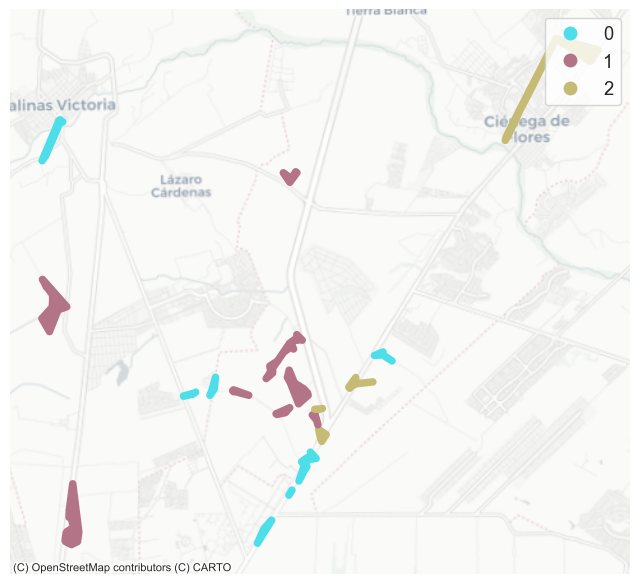

In [233]:
sns.set_theme(style="ticks", font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 8))
(
    df_polygons.assign(geometry=lambda df: df["geometry"].buffer(100)).plot(
        column="economic_cluster",
        ax=ax,
        cmap=make_random_cmap(len(df_polygons["economic_cluster"].unique()), seed=1),
        lw=0,
        legend=True,
        categorical=True,
    )
)
ax.axis("off")
cx.add_basemap(ax, crs=df_polygons.crs, zoom=12, source=cx.providers.CartoDB.Positron)
fig.savefig(subfigure_path / "clusters_map.jpg", bbox_inches="tight", dpi=300)

## Counts

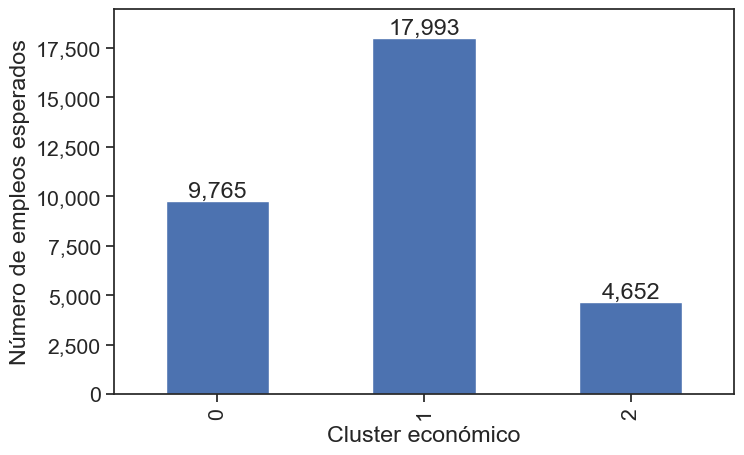

In [234]:
sns.set_theme(style="ticks", font_scale=1.4)
fig, ax = plt.subplots(figsize=(8, 5))
plot_num_jobs(df_points, ax=ax)
ax.set_ylim(0, ax.get_ylim()[1] * 1.03)
fig.savefig(subfigure_path / "num_jobs.jpg", bbox_inches="tight", dpi=300)

## Location quotient

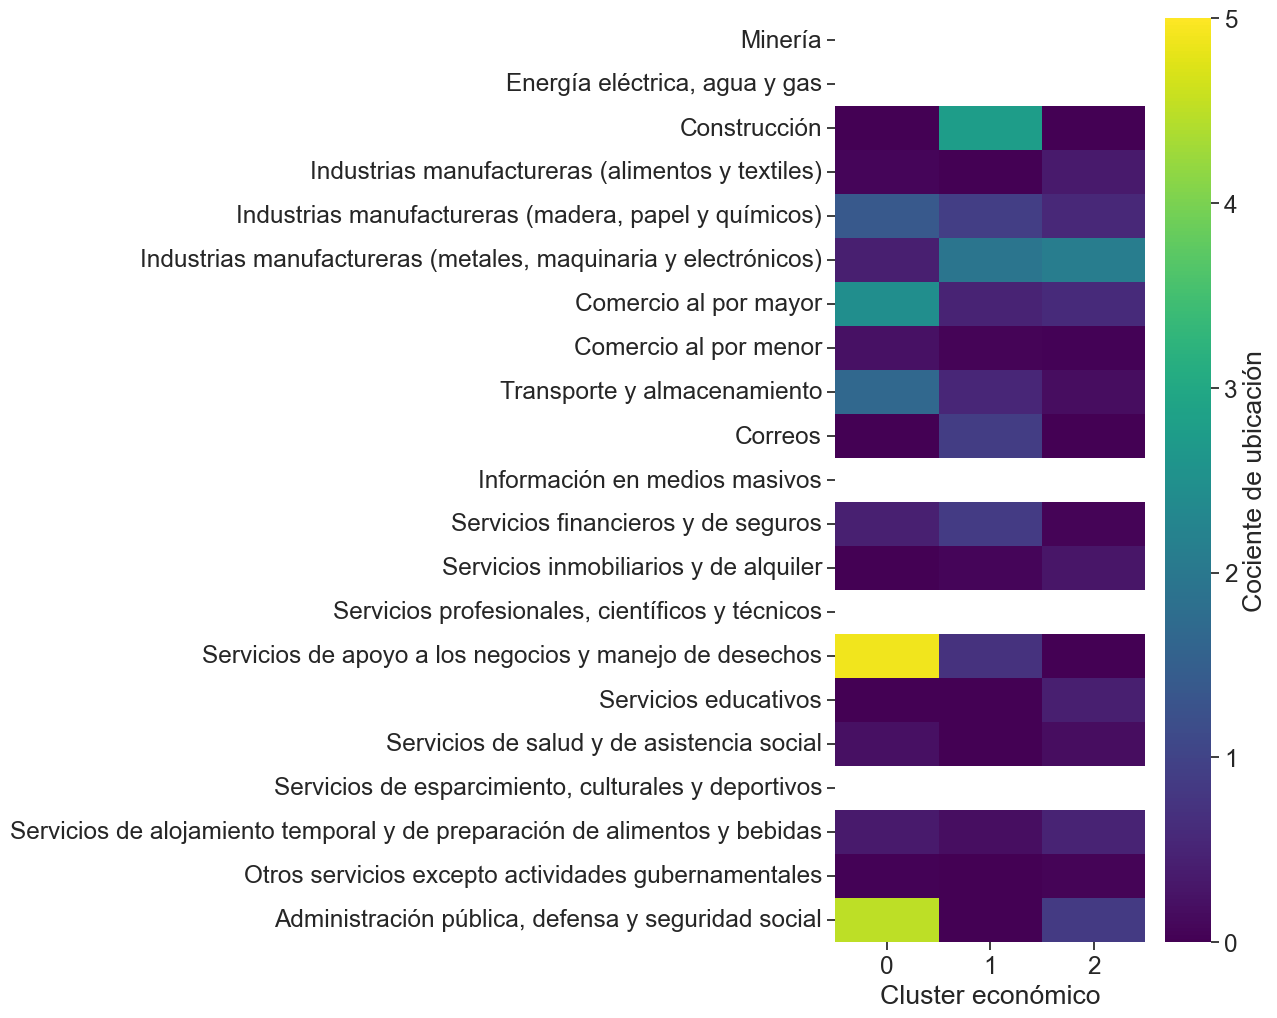

In [235]:
sns.set_theme(style="ticks", font_scale=1.6)
fig, ax = plt.subplots(figsize=(5, 12))
plot_location_quotient(df_points, ax=ax, level=2, heatmap_kws={"vmax": 5})
fig.savefig(subfigure_path / "location_quotient.jpg", bbox_inches="tight", dpi=300)

## Distribution

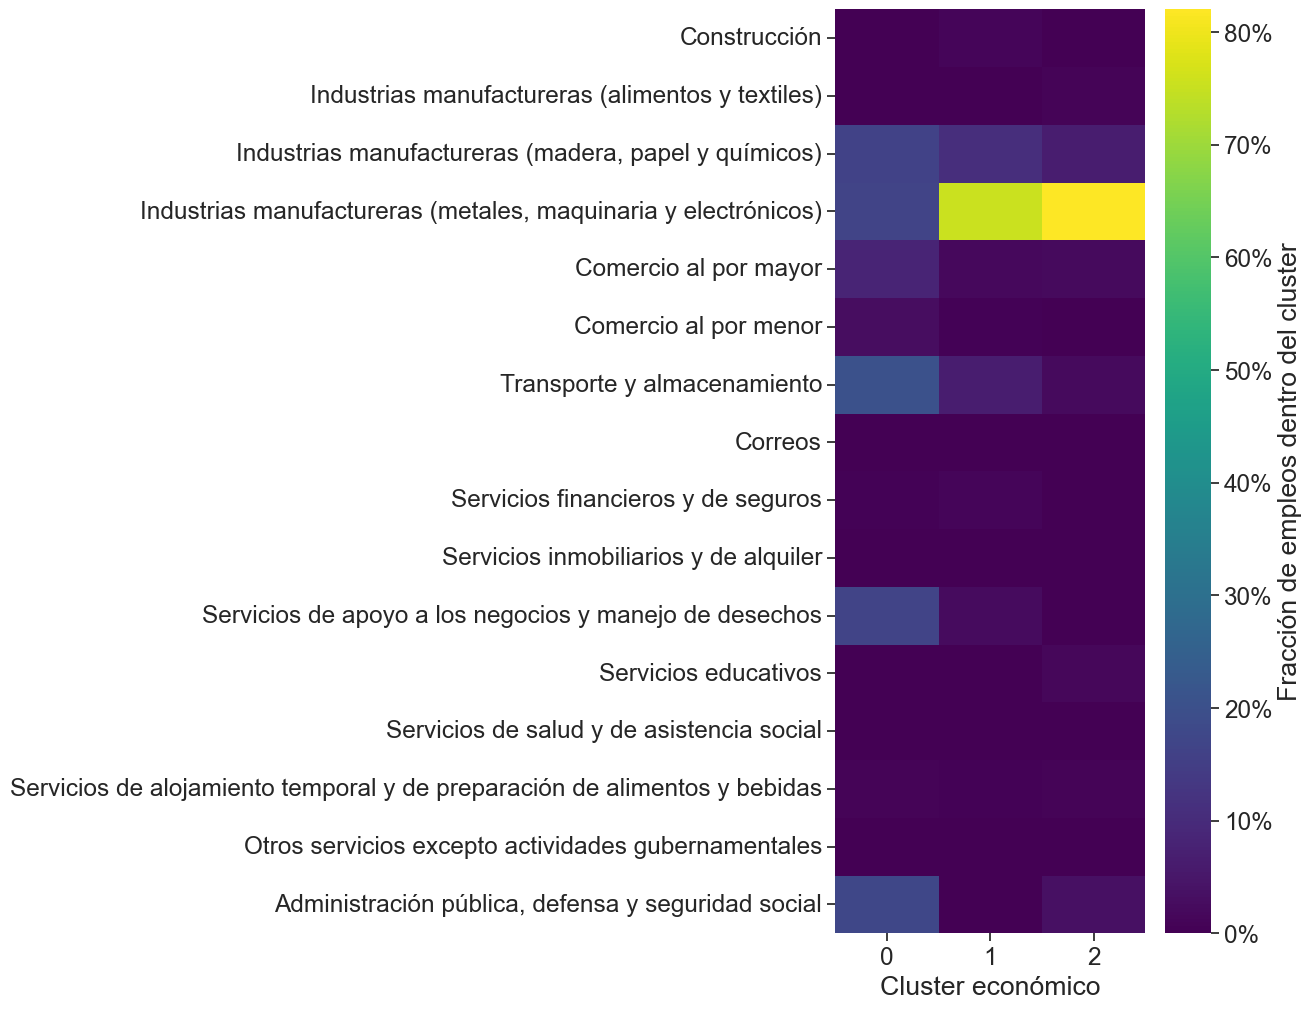

In [236]:
sns.set_theme(style="ticks", font_scale=1.6)
fig, ax = plt.subplots(figsize=(5, 12))
plot_cluster_distribution(df_points, ax=ax, level=2)
fig.savefig(subfigure_path / "cluster_distribution.jpg", bbox_inches="tight", dpi=300)

## Centroid

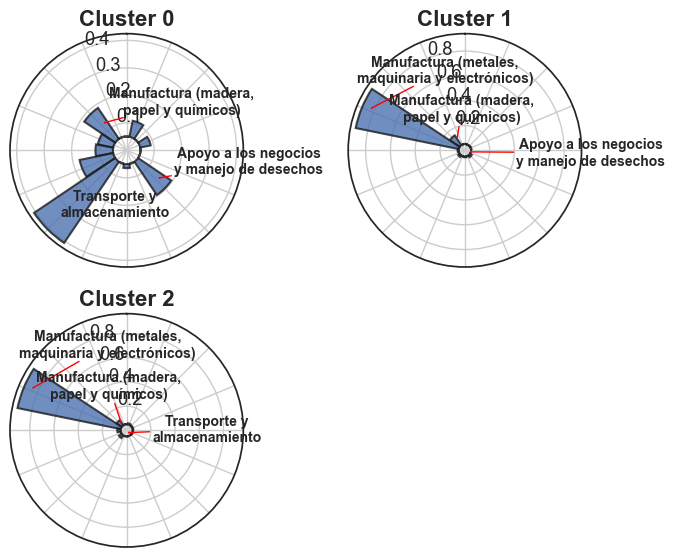

In [237]:
sns.set_theme(style="ticks", font_scale=1.2)
fig, _ = plot_centroids(df_points, level=2, annotate_top=True)
fig.savefig(subfigure_path / "centroids.jpg", bbox_inches="tight", dpi=300)